# Data Preperation - revised based on Kyle Whynott’s CPSC 483 Intro to ML course

## 1. Data Set Selection

### Sources to Acquire Datasets From

- [Kaggle](https://www.kaggle.com/datasets)

- [UCI Machine Learning Repository](https://archive.ics.uci.edu/)

- [Data.Gov](https://data.gov/)

- [World Bank Open Data](https://data.worldbank.org/)

- [Awesome Public Datsets](https://github.com/awesomedata/awesome-public-datasets)

### Code Documentation

- [Numpy](https://numpy.org/)

- [Pandas](https://pandas.pydata.org/)

## 2. Import the Dataset

In [44]:
import numpy as np
import pandas as pd

In [45]:
# Show all columns in Jupyter Lab using Pandas
pd.set_option('display.max_columns', None)

In [46]:
# Insert Dataset Here (Code to Be Completed)
# Option1 :
# if you use colab, you will have to mount Google Drive
import  numpy as np
import pandas as pd
# your path is now "/content/drive/MyDrive/Colab Notebooks/dataset/air_quality/AirQualityUCI.csv"
df = pd.read_csv(
    "dataset/air_quality/AirQualityUCI.csv",
    sep=";",
    decimal=","
)
# Option 2
# If you use your own IDE (VS Code, PyCharm, etc.),
# and your working directory is the project root,
# you can load the dataset using a relative path:
#df = pd.read_csv("./dataset/air_quality/AirQualityUCI.csv", sep=";",decimal=",")

In [47]:
df.head()

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
0,10/03/2004,18.00.00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578,NaN,NaN
1,10/03/2004,19.00.00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255,NaN,NaN
2,10/03/2004,20.00.00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502,NaN,NaN
3,10/03/2004,21.00.00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867,NaN,NaN
4,10/03/2004,22.00.00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888,NaN,NaN


## 3. Look for Data that Needs to Be Dropped / Cleaned

In [48]:
# Drop Rows with NaN values ('how' indicates that all rows must contain NaN values to be dropped)
# Code to Be Completed Here
# this dataset uses -200 to indicate missing values
#load the dataset again just to show the difference
df = pd.read_csv(
    "dataset/air_quality/AirQualityUCI.csv",
    sep=";",
    decimal=","
)
data_sz_b4_drop = len(df) #number of rows before cleaning

#To do list for cleaning the data
df = df.replace(-200, np.nan) #replacing -200 with NaN

df = df.dropna()   # drop empty columns with all “NaN / empty”
df = df.dropna() #drop rows with NaN values , by default axis=0, only one NaN value is enough to drop the row
# check how many rows left after cleaning


In [49]:
display(df)

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16


In [50]:
#Too less data left after dropping rows, so we will try another method-> inserting median values instead of NaN
# Insert Dataset Here (Code to Be Completed)
#load the dataset again just to show the difference
df = pd.read_csv(
    "dataset/air_quality/AirQualityUCI.csv",
    sep=";",
    decimal=","
)
#To do list for cleaning the data (keep more data this time)

df = df.replace(-200, np.nan) #replacing -200 with NaN
df = df.dropna()   # drop empty columns with all “NaN / empty”
df = df.fillna(df.median(numeric_only=True)) # fill-in median
after = len(df)

In [51]:
display(df)

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16


In [52]:
target = "CO(GT)"
X2 = df.drop(columns=[target]) #X features
y2 = df[target] #y: label

In [53]:
X2.shape  # (n_samples, n_features)
y2.shape  # (n_samples,)
print(X2.shape)
print(y2.shape)

(0, 16)
(0,)


## 4. Split the data into Training(70%)/Valitation(15%)/Testing(%15)

In [57]:
from sklearn.model_selection import train_test_split

# make sure we actually have some data before trying to split
if X2.empty or y2.empty:
    # reload & clean the CSV the way we did earlier,
    # but don’t drop rows containing NaN before we fill them
    df = pd.read_csv(
        "dataset/air_quality/AirQualityUCI.csv",
        sep=";",
        decimal=","
    )
    df = df.replace(-200, np.nan)                     # mark missing values
    df = df.dropna(axis=1, how="all")                 # drop any all‑NaN columns
    df = df.fillna(df.median(numeric_only=True))      # impute medians

    target = "CO(GT)"
    X2 = df.drop(columns=[target])
    y2 = df[target]

X_train, X_temp, y_train, y_temp = train_test_split(
    X2, y2,
    test_size=0.50,      # half of the samples go into the temporary set
    random_state=42
)

print(X_train.shape)  # (n_samples_train, n_features)
print(y_train.shape)  # (n_labels_train,)
print(X_train.shape)  # (n_samples_train, n_features)
print(y_train.shape)  # (n_labels_train,)

(4735, 14)
(4735,)
(4735, 14)
(4735,)


In [58]:
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,      # split 30% into 15% / 15%
    random_state=42
)
print(X_val.shape)  # (n_samples_train, n_features)
print(y_val.shape)  # (n_labels_train,)
print(X_test.shape)  # (n_samples_train, n_features)
print(y_test.shape)  # (n_labels_train,)

(2368, 14)
(2368,)
(2368, 14)
(2368,)


## 5. Now, let's use the built-in python code from the UCI database  
### Another method to load the datasset

In [ ]:
# Did it before, %pip install ucimlrepo, so skipping that step

In [59]:
import ucimlrepo
print("ucimlrepo is installed")

ucimlrepo is installed


In [60]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
air_quality = fetch_ucirepo(id=360)

# data (as pandas dataframes)
X = air_quality.data.features
y = air_quality.data.targets

# metadata
print(air_quality.metadata)

# variable information
print(air_quality.variables)

{'uci_id': 360, 'name': 'Air Quality', 'repository_url': 'https://archive.ics.uci.edu/dataset/360/air+quality', 'data_url': 'https://archive.ics.uci.edu/static/public/360/data.csv', 'abstract': 'Contains the responses of a gas multisensor device deployed on the field in an Italian city. Hourly responses averages are recorded along with gas concentrations references from a certified analyzer. ', 'area': 'Computer Science', 'tasks': ['Regression'], 'characteristics': ['Multivariate', 'Time-Series'], 'num_instances': 9358, 'num_features': 15, 'feature_types': ['Real'], 'demographics': [], 'target_col': None, 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2008, 'last_updated': 'Sun Mar 10 2024', 'dataset_doi': '10.24432/C59K5F', 'creators': ['Saverio Vito'], 'intro_paper': {'ID': 420, 'type': 'NATIVE', 'title': 'On field calibration of an electronic nose for benzene estimation in an urban pollution monitoring scenario', 'authors': 

In [61]:
# print details of metadata (find indication of missing values)

from pprint import pprint
pprint(air_quality.metadata)

{'abstract': 'Contains the responses of a gas multisensor device deployed on '
             'the field in an Italian city. Hourly responses averages are '
             'recorded along with gas concentrations references from a '
             'certified analyzer. ',
 'additional_info': {'citation': None,
                     'funded_by': None,
                     'instances_represent': None,
                     'preprocessing_description': None,
                     'purpose': None,
                     'recommended_data_splits': None,
                     'sensitive_data': None,
                     'summary': 'The dataset contains 9358 instances of hourly '
                                'averaged responses from an array of 5 metal '
                                'oxide chemical sensors embedded in an Air '
                                'Quality Chemical Multisensor Device. The '
                                'device was located on the field in a '
                            

In [62]:
X = air_quality.data.features

In [63]:
print(X.shape)

(9357, 15)


In [64]:
display(X.head(10))#show first 10 rows

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,3/10/2004,18:00:00,2.6,1360,150,11.9,1046,166,1056,113,1692,1268,13.6,48.9,0.7578
1,3/10/2004,19:00:00,2.0,1292,112,9.4,955,103,1174,92,1559,972,13.3,47.7,0.7255
2,3/10/2004,20:00:00,2.2,1402,88,9.0,939,131,1140,114,1555,1074,11.9,54.0,0.7502
3,3/10/2004,21:00:00,2.2,1376,80,9.2,948,172,1092,122,1584,1203,11.0,60.0,0.7867
4,3/10/2004,22:00:00,1.6,1272,51,6.5,836,131,1205,116,1490,1110,11.2,59.6,0.7888
5,3/10/2004,23:00:00,1.2,1197,38,4.7,750,89,1337,96,1393,949,11.2,59.2,0.7848
6,3/11/2004,0:00:00,1.2,1185,31,3.6,690,62,1462,77,1333,733,11.3,56.8,0.7603
7,3/11/2004,1:00:00,1.0,1136,31,3.3,672,62,1453,76,1333,730,10.7,60.0,0.7702
8,3/11/2004,2:00:00,0.9,1094,24,2.3,609,45,1579,60,1276,620,10.7,59.7,0.7648
9,3/11/2004,3:00:00,0.6,1010,19,1.7,561,-200,1705,-200,1235,501,10.3,60.2,0.7517


In [65]:
#y is currently empty dataframe,
display(y)
#to move the CO from features to target
y = X["CO(GT)"]
X = X.drop(columns=["CO(GT)"])

None

In [66]:
#Show more details about the data
type(X)
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 9357 entries, 0 to 9356
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           9357 non-null   str    
 1   Time           9357 non-null   str    
 2   PT08.S1(CO)    9357 non-null   int64  
 3   NMHC(GT)       9357 non-null   int64  
 4   C6H6(GT)       9357 non-null   float64
 5   PT08.S2(NMHC)  9357 non-null   int64  
 6   NOx(GT)        9357 non-null   int64  
 7   PT08.S3(NOx)   9357 non-null   int64  
 8   NO2(GT)        9357 non-null   int64  
 9   PT08.S4(NO2)   9357 non-null   int64  
 10  PT08.S5(O3)    9357 non-null   int64  
 11  T              9357 non-null   float64
 12  RH             9357 non-null   float64
 13  AH             9357 non-null   float64
dtypes: float64(4), int64(8), str(2)
memory usage: 1023.6 KB


In [67]:
# Describe the data (include some statistics)
#As you can see there are lots of "-200" values in the dataset, they are invalid
X.describe()

,PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
count,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000
mean,1048.990061,-159.090093,1.865683,894.595276,168.616971,794.990168,58.148873,1391.479641,975.072032,9.778305,39.485380,-6.837604
std,329.832710,139.789093,41.380206,342.333252,257.433866,321.993552,126.940455,467.210125,456.938184,43.203623,51.216145,38.976670
min,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000
25%,921.000000,-200.000000,4.000000,711.000000,50.000000,637.000000,53.000000,1185.000000,700.000000,10.900000,34.100000,0.692300
50%,1053.000000,-200.000000,7.900000,895.000000,141.000000,794.000000,96.000000,1446.000000,942.000000,17.200000,48.600000,0.976800
75%,1221.000000,-200.000000,13.600000,1105.000000,284.000000,960.000000,133.000000,1662.000000,1255.000000,24.100000,61.900000,1.296200
max,2040.000000,1189.000000,63.700000,2214.000000,1479.000000,2683.000000,340.000000,2775.000000,2523.000000,44.600000,88.700000,2.231000


In [68]:
#check for missing values
X.isna().sum()

Date             0
Time             0
PT08.S1(CO)      0
NMHC(GT)         0
C6H6(GT)         0
PT08.S2(NMHC)    0
NOx(GT)          0
PT08.S3(NOx)     0
NO2(GT)          0
PT08.S4(NO2)     0
PT08.S5(O3)      0
T                0
RH               0
AH               0
dtype: int64

In [69]:
#check first column values
X.iloc[:, 0]

0       3/10/2004
1       3/10/2004
2       3/10/2004
3       3/10/2004
4       3/10/2004
          ...    
9352     4/4/2005
9353     4/4/2005
9354     4/4/2005
9355     4/4/2005
9356     4/4/2005
Name: Date, Length: 9357, dtype: str

In [70]:
#check data type of first column
#type(X.iloc[:, 0])
#check data type of 4th column
type(X.iloc[:, 3])
display(X.iloc[0:10, 3])
display(X.head(10))

0    150
1    112
2     88
3     80
4     51
5     38
6     31
7     31
8     24
9     19
Name: NMHC(GT), dtype: int64

,Date,Time,PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,3/10/2004,18:00:00,1360,150,11.9,1046,166,1056,113,1692,1268,13.6,48.9,0.7578
1,3/10/2004,19:00:00,1292,112,9.4,955,103,1174,92,1559,972,13.3,47.7,0.7255
2,3/10/2004,20:00:00,1402,88,9.0,939,131,1140,114,1555,1074,11.9,54.0,0.7502
3,3/10/2004,21:00:00,1376,80,9.2,948,172,1092,122,1584,1203,11.0,60.0,0.7867
4,3/10/2004,22:00:00,1272,51,6.5,836,131,1205,116,1490,1110,11.2,59.6,0.7888
5,3/10/2004,23:00:00,1197,38,4.7,750,89,1337,96,1393,949,11.2,59.2,0.7848
6,3/11/2004,0:00:00,1185,31,3.6,690,62,1462,77,1333,733,11.3,56.8,0.7603
7,3/11/2004,1:00:00,1136,31,3.3,672,62,1453,76,1333,730,10.7,60.0,0.7702
8,3/11/2004,2:00:00,1094,24,2.3,609,45,1579,60,1276,620,10.7,59.7,0.7648
9,3/11/2004,3:00:00,1010,19,1.7,561,-200,1705,-200,1235,501,10.3,60.2,0.7517


### You can use similar way to split the training/validation/testing data
### Please be aware that -200 is not removed in X and y (using the direct method to loaded in UCI Air Quality dataset)
### In the next section, we still use the "df" datafram we originally loaded from *CSV file (invalid -200 is replaced by median)  
--------------------------------------------------------------------------------------------------------------------------------------

## CO(GT) Regression Demo

This section shows two regressions to predict **CO(GT)**:

1. **Baseline (1 feature, not a sensor):** use only **NOx(GT)**
2. **Improved (multiple meaningful features, no CO sensor ):** use **NOx(GT), NO2(GT), NMHC(GT), T, RH, AH**

> Note: We intentionally **exclude** `PT08.S1(CO)` (the CO sensor) in the improved model to avoid leakage.


In [71]:
# Ensure the cleaned dataframe `df` exists
import pandas as pd
import numpy as np

required_cols = ["CO(GT)", "NOx(GT)", "NO2(GT)", "NMHC(GT)", "T", "RH", "AH"]

# Keep only rows with the columns we need
reg_df = df[required_cols].dropna().copy()
print("Regression dataset shape:", reg_df.shape)
reg_df.head()


Regression dataset shape: (9471, 7)


,CO(GT),NOx(GT),NO2(GT),NMHC(GT),T,RH,AH
0,2.6,166.0,113.0,150.0,13.6,48.9,0.7578
1,2.0,103.0,92.0,112.0,13.3,47.7,0.7255
2,2.2,131.0,114.0,88.0,11.9,54.0,0.7502
3,2.2,172.0,122.0,80.0,11.0,60.0,0.7867
4,1.6,131.0,116.0,51.0,11.2,59.6,0.7888


### 1) Baseline: predict CO(GT) using **one** feature (NOx(GT))

In [85]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np
# scikit-learn is a Python library that provides ready-to-use machine learning algorithms
# for documentation of scikit-learn, please check https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html

X_base = reg_df[["NOx(GT)"]] #we didn't do normalization or standardization because only "one" feature, and linear regression is not sensitive to feature scaling
y = reg_df["CO(GT)"]

#Because no model selection, we only slit the data into train and test sets, no validation set needed
X_train, X_test, y_train, y_test = train_test_split(
    X_base, y, test_size=0.2, random_state=42
)

baseline_model = LinearRegression()#
baseline_model.fit(X_train, y_train)

y_pred_base = baseline_model.predict(X_test)

print("Baseline (1 feature = NOx(GT))")

print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_base)))
#Note:RMSE tells you how big the errors are; R² tells you how useful the model is compared to always predicting the mean of y_train.

#### To do: print R^2 : it means how well your model explains the variability in the data
####----------------------------------------------------------------------------------------
print(f"R^2: {r2_score(y_test, y_pred_base)}") #R² = 0.75 means the model explains 75% of the variability in the data, which is pretty good for a regression model.

Baseline (1 feature = NOx(GT))
RMSE: 0.8425702990789335
R^2: 0.6017780854611104


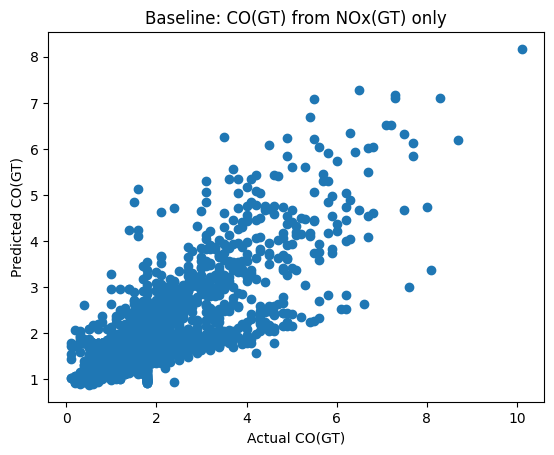

In [73]:
# Optional: quick visualization (actual vs predicted)
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(y_test, y_pred_base)
plt.xlabel("Actual CO(GT)")
plt.ylabel("Predicted CO(GT)")
plt.title("Baseline: CO(GT) from NOx(GT) only")
plt.show()


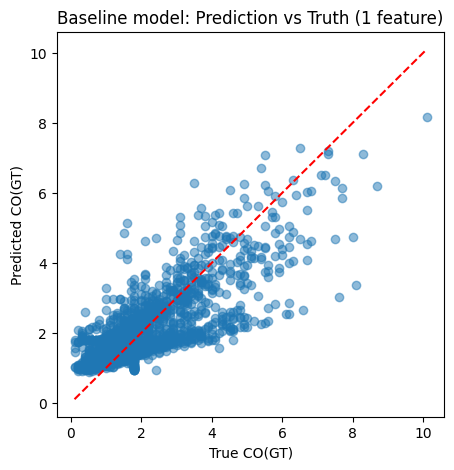

In [74]:
#Baseline: Predicted vs True plot (one feature)
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 5))

# scatter of predictions vs truth
plt.scatter(y_test, y_pred_base, alpha=0.5) #alpha = 0.5 → 50% transparent

# perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--"
)

plt.xlabel("True CO(GT)")
plt.ylabel("Predicted CO(GT)")
plt.title("Baseline model: Prediction vs Truth (1 feature)")
plt.show()

#If predictions were perfect, all points would lie on the red diagonal.

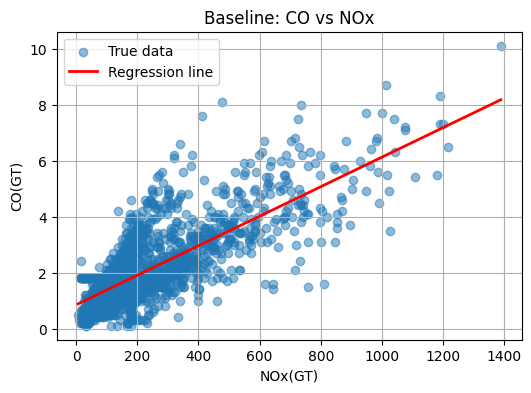

In [86]:
#Baseline: one feature → regression line
import matplotlib.pyplot as plt
import numpy as np

# Sort values for a clean line
idx = np.argsort(X_test.values.flatten())#If you don’t sort, the red “regression line” will look messy or zig-zaggy, even though the model is correct

plt.figure(figsize=(6, 4))
plt.scatter(X_test.values, y_test, alpha=0.5, label="True data")
plt.plot(
    X_test.values[idx],
    y_pred_base[idx],
    color="red",
    linewidth=2,
    label="Regression line"
)

plt.xlabel("NOx(GT)")
plt.ylabel("CO(GT)")
plt.title("Baseline: CO vs NOx")
plt.legend()
plt.grid(True)
plt.show()


### 2) Improved: predict CO(GT) using multiple meaningful features (no CO sensor)

In [77]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

features = ["NOx(GT)", "NO2(GT)", "NMHC(GT)", "T", "RH", "AH"]
X = reg_df[features]
y = reg_df["CO(GT)"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Let's use Ridge model:  Ridge helps when features are correlated (common in air quality data)
# Pipeline is a class provided by the scikit-learn library that allows you to chain together multiple steps in a machine learning workflow, such as preprocessing and modeling, into a single object.
# This makes it easier to manage and apply the same transformations to both training and testing data.

model = Pipeline([
    ("scaler", StandardScaler()), #normalization.
    ("ridge", Ridge(alpha=1.0))
])

#Note : if you don't want to combine two steps, you can do them separately like this:
#scaler = StandardScaler()
#ridge = Ridge(alpha=1.0)
#For training
#X_train_scaled = scaler.fit_transform(X_train)
#ridge.fit(X_train_scaled, y_train)
#for prediction
#ridge.predict(scaler.transform(X_test))

#feed the training data to the model, fit means to train the model using the training data (parameters will be learned during the training process)
model.fit(X_train, y_train)
#Let's use the test data to evaluate the model
y_pred = model.predict(X_test)

print("Improved (multiple features)")
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred))) #On average, predictions are off by about RMSE units of CO(GT).
#Note:RMSE tells you how big the errors are; R² tells you how useful the model is compared to always predicting the mean of y_train.

#### To do: print R^2 : it means how well your model explains the variability in the data
####-------------------------------------------------------------------------------
print("R²:", r2_score(y_test, y_pred)) #R² = 0.75 means the model explains 75% of the variability in the data, which is pretty good for a regression model.

Improved (multiple features)
RMSE: 0.7069925642467262
R²: 0.7196228891277628


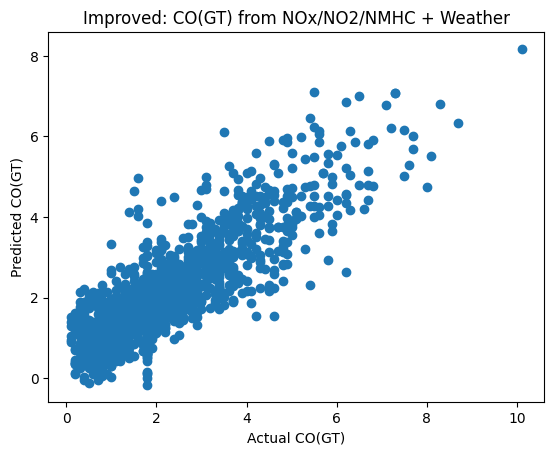

In [78]:
# Optional: visualization (actual vs predicted)
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual CO(GT)")
plt.ylabel("Predicted CO(GT)")
plt.title("Improved: CO(GT) from NOx/NO2/NMHC + Weather")
plt.show()


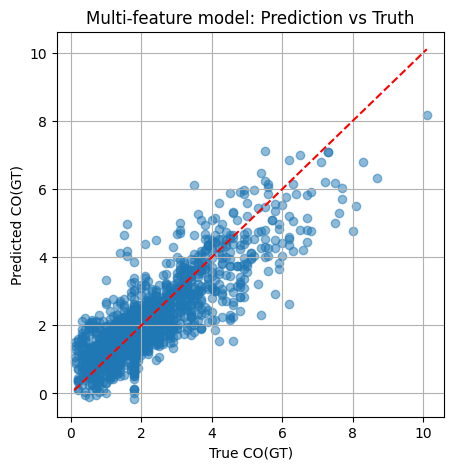

In [87]:
#How to visualize a multi-feature regression model’s predictions vs true values?
#Option A : Predicted vs True plot
#“If predictions were perfect, all points would lie on the red diagonal.”

plt.figure(figsize=(5, 5))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--"
)

plt.xlabel("True CO(GT)")
plt.ylabel("Predicted CO(GT)")
plt.title("Multi-feature model: Prediction vs Truth")
plt.grid(True)
plt.show()


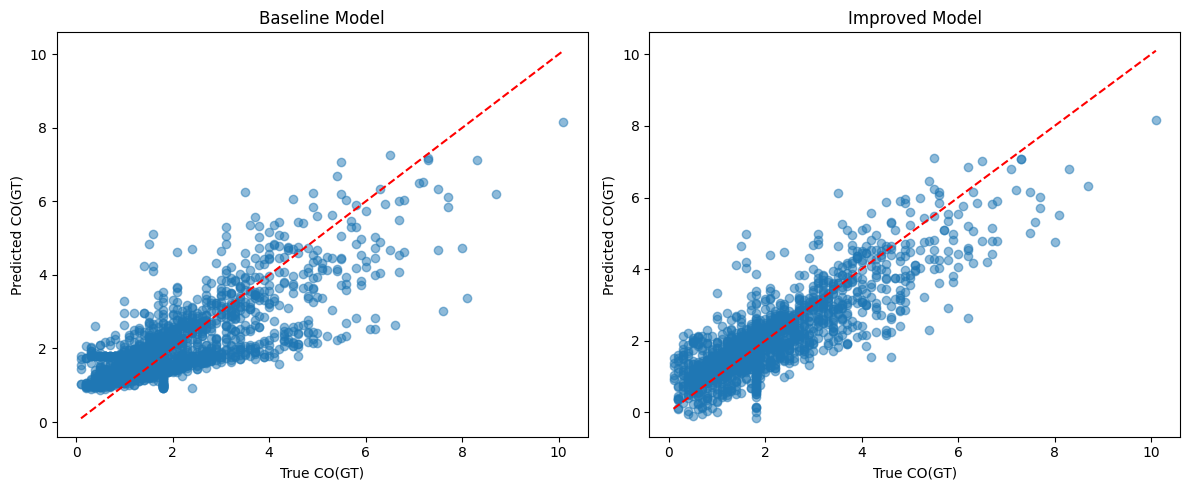

In [91]:
#side by side comparison of baseline vs improved
import matplotlib.pyplot as plt

# Create 1 row, 2 columns of subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Baseline model
ax1.scatter(y_test, y_pred_base, alpha=0.5)
ax1.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
ax1.set_xlabel("True CO(GT)")
ax1.set_ylabel("Predicted CO(GT)")
ax1.set_title("Baseline Model")


# Plot 2: Improved model
ax2.scatter(y_test, y_pred, alpha=0.5)
ax2.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
ax2.set_xlabel("True CO(GT)")
ax2.set_ylabel("Predicted CO(GT)")
ax2.set_title("Improved Model")

plt.tight_layout()
plt.show()

In [81]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np
# Display metrics side by side
rmse_baseline = np.sqrt(mean_squared_error(y_test, y_pred_base))
rmse_improved = np.sqrt(mean_squared_error(y_test, y_pred))
r2_baseline = r2_score(y_test, y_pred_base)
r2_improved = r2_score(y_test, y_pred)
#### To do: add R^2 for comparison : it means how well your model explains the variability in the data

print("=" * 50)
print("RMSE Comparison")
print("=" * 50)
print(f"Baseline Model RMSE:  {rmse_baseline:.4f}")
print(f"Improved Model RMSE:  {rmse_improved:.4f}")
print(f"Improvement:          {((rmse_baseline - rmse_improved) / rmse_baseline * 100):.2f}%")
print("=" * 50)


print("=" * 50)
print("R^2 Comparison??????? please complete")
print(f"Baseline Model R^2:  {r2_baseline:.4f}")
print(f"Improved Model R^2:  {r2_improved:.4f}")
print(f"Improvement:         {((r2_improved - r2_baseline) / r2_baseline * 100):.2f}%")
print("=" * 50)


RMSE Comparison
Baseline Model RMSE:  0.8426
Improved Model RMSE:  0.7070
Improvement:          16.09%
R^2 Comparison??????? please complete
Baseline Model R^2:  0.6018
Improved Model R^2:  0.7196
Improvement:         19.58%


### (HW2)  Part I
### 3) Select another candidate model to predict CO(GT) using multiple meaningful features (no CO sensor)
#### Please use similar method shown in 2) but try different model for example Lasso Regression (https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html)

#### Please make sure you include the following parts (they can be found in (2))
#### 1. Predicted vs True plot (red diagonal line is displayed as a ideal prediction)
#### 2. Side by side comparison (plots) of the model used in (2) vs the model used in (3)-> this HW Part I section
#### 3. Display metrics side by side


In [ ]:
# please add your HW Part I cells here

In [ ]:
# Import libraries for modeling

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso

# Construct a regression model using Lasso regression, which is a linear model that estimates sparse coefficients. It is useful when you have many features, and you want to perform feature selection by shrinking some coefficients to zero.
features = ["NOx(GT)", "NO2(GT)", "NMHC(GT)", "T", "RH", "AH"]
X = reg_df[features]
y = reg_df["CO(GT)"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", Lasso(alpha=0.1))
])

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Lasso Regression (multiple features)")
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R²:", r2_score(y_test, y_pred))

Lasso Regression (multiple features)
RMSE: 0.7405591657448352
R²: 0.6923673780946797


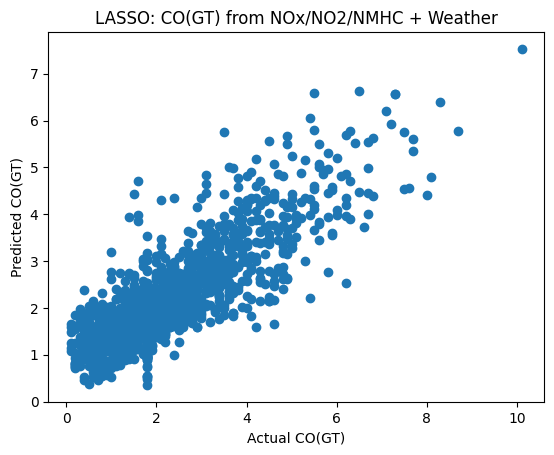

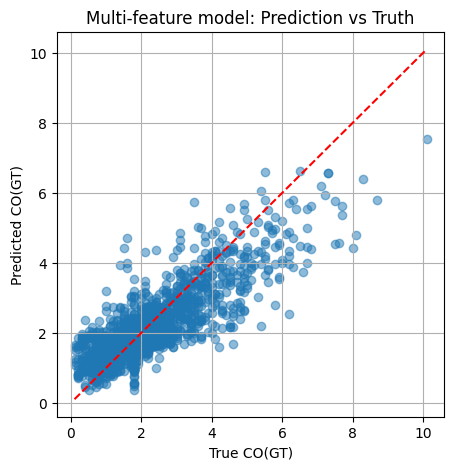

In [118]:
# Plot results
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual CO(GT)")
plt.ylabel("Predicted CO(GT)")
plt.title("LASSO: CO(GT) from NOx/NO2/NMHC + Weather")
plt.figure(figsize=(5, 5))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--"
)

plt.xlabel("True CO(GT)")
plt.ylabel("Predicted CO(GT)")
plt.title("Multi-feature model: Prediction vs Truth")
plt.grid(True)
plt.show()
plt.show()

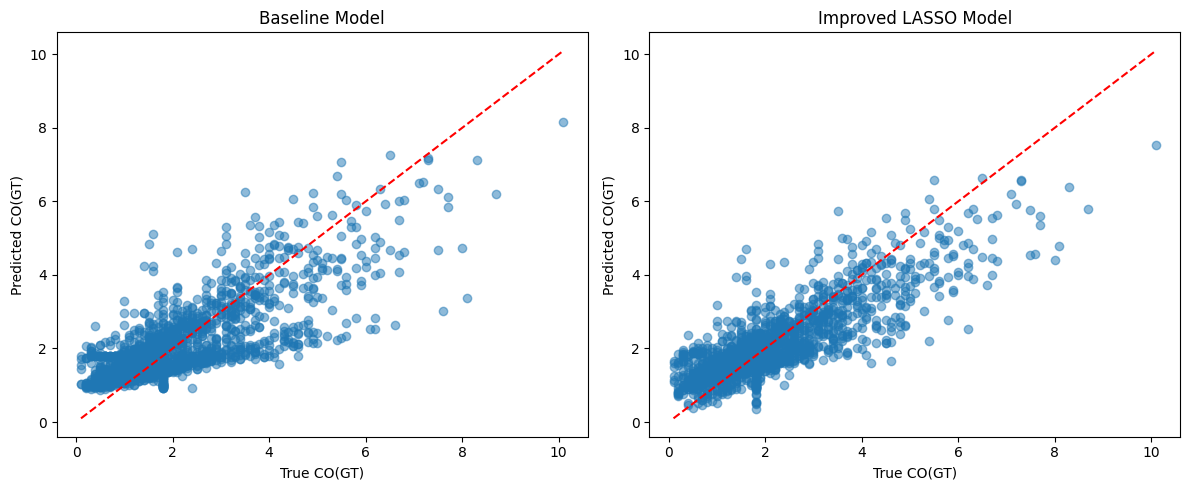

In [119]:
import matplotlib.pyplot as plt

# Create 1 row, 2 columns of subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Baseline model
ax1.scatter(y_test, y_pred_base, alpha=0.5)
ax1.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
ax1.set_xlabel("True CO(GT)")
ax1.set_ylabel("Predicted CO(GT)")
ax1.set_title("Baseline Model")


# Plot 2: Improved model
ax2.scatter(y_test, y_pred, alpha=0.5)
ax2.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
ax2.set_xlabel("True CO(GT)")
ax2.set_ylabel("Predicted CO(GT)")
ax2.set_title("Improved LASSO Model")

plt.tight_layout()
plt.show()

In [130]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# Display metrics side by side
rmse_baseline = np.sqrt(mean_squared_error(y_test, y_pred_base))
rmse_improved = np.sqrt(mean_squared_error(y_test, y_pred))
r2_baseline = r2_score(y_test, y_pred_base)
r2_improved = r2_score(y_test, y_pred)

print("=" * 50)
print("RMSE Comparison")
print("=" * 50)
print(f"Baseline Model RMSE:  {rmse_baseline:.4f}")
print(f"Improved Model RMSE:  {rmse_improved:.4f}")
print(f"Improvement:          {((rmse_baseline - rmse_improved) / rmse_baseline * 100):.2f}%")
print("=" * 50)


print("=" * 50)
print("R^2 Comparison: ")
print(f"Baseline Model R^2:  {r2_baseline:.4f}")
print(f"Improved Model R^2:  {r2_improved:.4f}")
print(f"Improvement:         {((r2_improved - r2_baseline) / r2_baseline * 100):.2f}%")
print("=" * 50)


RMSE Comparison
Baseline Model RMSE:  0.8426
Improved Model RMSE:  0.7406
Improvement:          12.11%
R^2 Comparison: 
Baseline Model R^2:  0.6018
Improved Model R^2:  0.6924
Improvement:         15.05%


### (HW2)  Part II
### 4) Based on previous model evaluaiton metric, you can pick one model with better performance
### Adjust the model parameters, ex. alpha value in Ridge model, then predict CO(GT) using multiple meaningful features (no CO sensor)
#### Please make sure you include the following parts (they can be found in (2))
#### 1. Predicted vs True plot (red diagonal line is displayed as a ideal prediction)
#### 2. Side by side comparison (plots) of the model you pick with the original parameter(s) and with the adjusted parameter(s)
#### 3. Display metrics side by side


Ridge Regression (multiple features)
RMSE: 0.7069936275763558
R^2: 0.7196220457426165


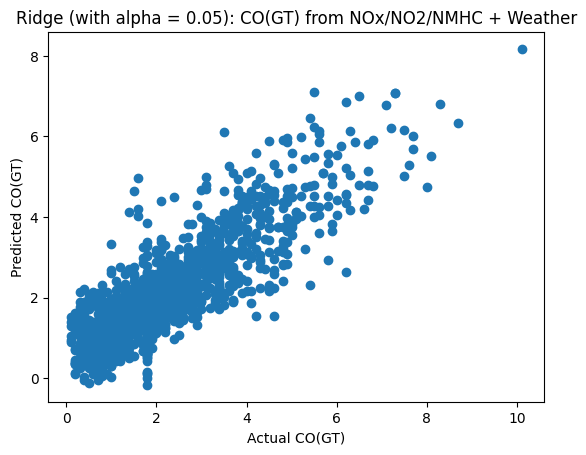

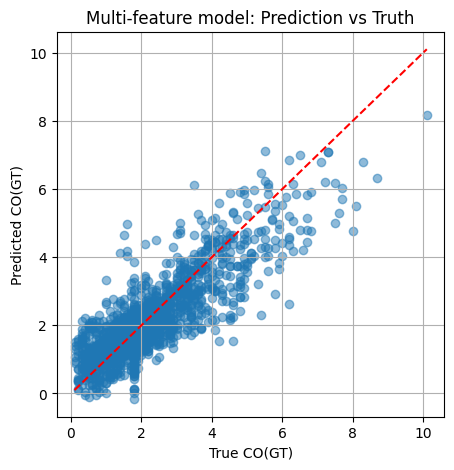

In [136]:
# please add your HW Part II here
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso

features = ["NOx(GT)", "NO2(GT)", "NMHC(GT)", "T", "RH", "AH"]
X = reg_df[features]
y = reg_df["CO(GT)"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=0.05))
])

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Ridge Regression (multiple features)")
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R^2:", r2_score(y_test, y_pred))

# Plot results
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual CO(GT)")
plt.ylabel("Predicted CO(GT)")
plt.title("Ridge (with alpha = 0.05): CO(GT) from NOx/NO2/NMHC + Weather")
plt.figure(figsize=(5, 5))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--"
)

plt.xlabel("True CO(GT)")
plt.ylabel("Predicted CO(GT)")
plt.title("Multi-feature model: Prediction vs Truth")
plt.grid(True)
plt.show()
plt.show()

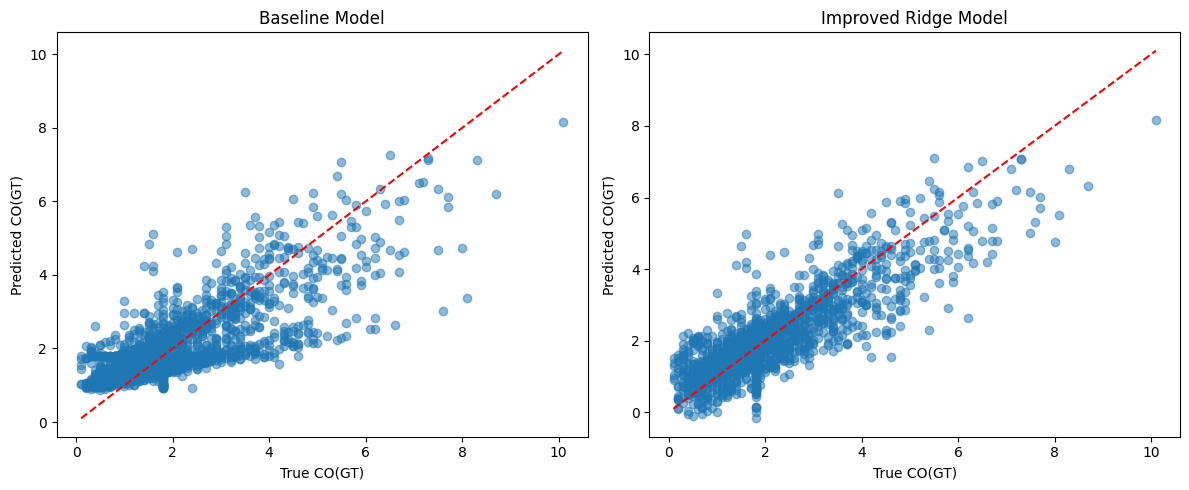

RMSE Comparison
Baseline Model RMSE:  0.8426
Improved Model RMSE:  0.7070
Improvement:          16.09%
R^2 Comparison: 
Baseline Model R^2:  0.6018
Improved Model R^2:  0.7196
Improvement:         19.58%


In [138]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

# Create 1 row, 2 columns of subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Baseline model
ax1.scatter(y_test, y_pred_base, alpha=0.5)
ax1.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
ax1.set_xlabel("True CO(GT)")
ax1.set_ylabel("Predicted CO(GT)")
ax1.set_title("Baseline Model")


# Plot 2: Improved model
ax2.scatter(y_test, y_pred, alpha=0.5)
ax2.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
ax2.set_xlabel("True CO(GT)")
ax2.set_ylabel("Predicted CO(GT)")
ax2.set_title("Improved Ridge Model")

plt.tight_layout()
plt.show()

# Display metrics side by side
rmse_baseline = np.sqrt(mean_squared_error(y_test, y_pred_base))
rmse_improved = np.sqrt(mean_squared_error(y_test, y_pred))
r2_baseline = r2_score(y_test, y_pred_base)
r2_improved = r2_score(y_test, y_pred)

print("=" * 50)
print("RMSE Comparison")
print("=" * 50)
print(f"Baseline Model RMSE:  {rmse_baseline:.4f}")
print(f"Improved Model RMSE:  {rmse_improved:.4f}")
print(f"Improvement:          {((rmse_baseline - rmse_improved) / rmse_baseline * 100):.2f}%")
print("=" * 50)


print("=" * 50)
print("R^2 Comparison: ")
print(f"Baseline Model R^2:  {r2_baseline:.4f}")
print(f"Improved Model R^2:  {r2_improved:.4f}")
print(f"Improvement:         {((r2_improved - r2_baseline) / r2_baseline * 100):.2f}%")
print("=" * 50)


(HW2) Part III

### Discussion: Model and Parameter Selection

Based on your evaluations from Part I and Part II, write a concise discussion addressing the following points:

1.  **Compare Model Performance:** How did the Lasso Regression model (from HW Part I, or any other model you selected) perform compared to the Ridge Regression model in predicting CO(GT)? Refer to RMSE and R^2 metrics.
2.  **Impact of Parameter Tuning:** How did adjusting the parameter in the Ridge/Lasso model affect its performance (as practived in HW Part II)? Provide evidence from your metrics.
3.  **Best Performing Model/Parameter:** Which model (and with which parameters) did you find to be the most effective for predicting CO(GT) and why? Justify your choice based on the evaluation metrics.



#### Please type your disussion for HW part III here ---> Below

# Question 1
The LASSO Regression model performed less than the Ridge Regression model in terms of predicting CO(GT). The comparison of the models are given below

```
==================================================
LASSO/Baseline RMSE Comparison
==================================================
Baseline Model RMSE:  0.8426
Improved Model RMSE:  0.7406
Improvement:          12.11%
==================================================
==================================================
R^2 Comparison: 
Baseline Model R^2:  0.6018
Improved Model R^2:  0.6924
Improvement:         15.05%
==================================================

==================================================
Improved Ridge/RMSE Comparison
==================================================
Baseline Model RMSE:  0.8426
Improved Model RMSE:  0.7070
Improvement:          16.09%
==================================================
==================================================
R^2 Comparison: 
Baseline Model R^2:  0.6018
Improved Model R^2:  0.7196
Improvement:         19.58%
==================================================
```

Lasso has only improved our baseline model by 15.05% while the Ridge model has improved our baseline model by 19.58%. This makes Ridge a more powerful model in predicting the numerical value of CO(GT). 

# Question 2

Adjusting the alpha (or regularization parameter) value can cause the model to overfit or underfit the data if not done correctly. For example, I changed the value of alpha for the Ridge model to be 0.05 instead of 0.1. This caused the model to fit the data better, but had also increased the risk of overfitting. Nonetheless, changing the value of alpha is a good way to fine-tune our model and to find a "sweet spot" (a point where bias and variance are balanced out) to minimize the error in our model. 

# Question 3

I think Ridge is the optimal model for predicting CO(GT) because compared to the evaluation metrics of the Lasso model, it has significantly improved the Baseline model by 20% whereas the Lasso model only improved the Baseline model by 15%. I think for handling datasets with more outliers I would build a Ridge model while for datasets that have less error I would use Lasso. 